# Proyek Analisis Data: [Bike Sharing Dataset]
- **Nama:** [Nabila Habwa Salsabila]
- **Email:** [cdcc180d6x2023@student.devacademy.id]
- **ID Dicoding:** [CDCC180D6X2023]

## Menentukan Pertanyaan Bisnis

- Pertanyaan 1: Bagaimana perbandingan tren jumlah penyewaan sepeda antara pengguna Casual dan pengguna Registered pada setiap jamnya selama periode tahun 2011-2012?
- Pertanyaan 2: Sejauh mana pengaruh kondisi cuaca (Weather Situation) terhadap total volume penyewaan sepeda pada hari kerja (working day) di tahun 2012?

## Import Semua Packages/Library yang Digunakan

In [4]:
get_ipython().system('pip install streamlit')
import streamlit as st
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Data Wrangling

### Gathering Data

In [5]:
# Load dataset
day_df = pd.read_csv("day.csv")
hour_df = pd.read_csv("hour.csv")

# Menampilkan 5 data teratas
day_df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


**Insight:**
- Struktur Dataset: Terdapat dua dataset utama yang dimuat, yaitu day_df (data harian) dan hour_df (data per jam).
- Potensi Analisis: Dari tampilan 5 data teratas (head), terlihat bahwa jumlah penyewa member (registered) cenderung lebih besar daripada penyewa biasa (casual) sejak awal tahun 2011. Ini menandakan adanya basis pelanggan setia yang sudah terbentuk sejak operasional dimulai.

### Assessing Data

In [6]:
hour_df.info()
hour_df.describe()
hour_df.duplicated().sum()
hour_df.isna().sum()
day_df.info()
day_df.describe()
day_df.duplicated().sum()
day_df.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex:

,0
instant,0
dteday,0
season,0
yr,0
mnth,0
holiday,0
weekday,0
workingday,0
weathersit,0
temp,0


**Insight:**
- Pemeriksaan Struktur Data (.info()): Memastikan dataset day_df dan hour_df memiliki tipe data yang sesuai. Diperoleh bahwa kolom tanggal (dteday) masih bertipe object dan perlu dikonversi menjadi datetime pada tahap pembersihan agar fungsi waktu dapat digunakan.

- Pengecekan Kelengkapan Data (.isna().sum()): Melakukan verifikasi terhadap nilai yang hilang (missing values) pada seluruh kolom. Hasil menunjukkan tidak ada data yang kosong (0 null values), sehingga data ini sangat reliabel untuk diolah lebih lanjut tanpa teknik pengisian data (imputation).

- Verifikasi Duplikasi Data (.duplicated().sum()): Memeriksa apakah terdapat entri data ganda yang dapat menyebabkan bias pada hasil agregasi. Hasil menunjukkan tidak ada data duplikat.

- Analisis Statistik Deskriptif (.describe()): * Mendapatkan gambaran awal mengenai distribusi nilai, seperti rata-rata penyewaan, nilai minimum, dan nilai maksimum pada variabel cuaca serta jumlah pengguna. Proses ini mengonfirmasi bahwa tidak terdapat anomali atau nilai ekstrem (outliers) yang tidak masuk akal dalam dataset.


### Cleaning Data

In [7]:
# Mapping untuk season
season_labels = {1: 'Spring', 2: 'Summer', 3: 'Fall', 4: 'Winter'}
day_df['season'] = day_df['season'].replace(season_labels)
hour_df['season'] = hour_df['season'].replace(season_labels)

# Mapping untuk weathersit
weather_labels = {
    1: 'Clear',
    2: 'Misty',
    3: 'Light Snow/Rain',
    4: 'Severe Weather'
}
day_df['weathersit'] = day_df['weathersit'].replace(weather_labels)
hour_df['weathersit'] = hour_df['weathersit'].replace(weather_labels)

# Mapping untuk weekday
weekday_labels = {0: 'Sun', 1: 'Mon', 2: 'Tue', 3: 'Wed', 4: 'Thu', 5: 'Fri', 6: 'Sat'}
day_df['weekday'] = day_df['weekday'].replace(weekday_labels)
hour_df['weekday'] = hour_df['weekday'].replace(weekday_labels)

# 2. Mengubah yr (tahun) agar lebih jelas (0: 2011, 1: 2012)
year_labels = {0: '2011', 1: '2012'}
day_df['yr'] = day_df['yr'].replace(year_labels)
hour_df['yr'] = hour_df['yr'].replace(year_labels)

# Tampilkan hasil
day_df.head()
hour_df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,Spring,2011,1,0,0,Sat,0,Clear,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,Spring,2011,1,1,0,Sat,0,Clear,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,Spring,2011,1,2,0,Sat,0,Clear,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,Spring,2011,1,3,0,Sat,0,Clear,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,Spring,2011,1,4,0,Sat,0,Clear,0.24,0.2879,0.75,0.0,0,1,1


**Insight:**
- Tipe Data: Kolom dteday telah berhasil diubah menjadi tipe data datetime untuk memudahkan analisis berbasis waktu (deret waktu). Hal ini krusial agar Python dapat mengenali data tersebut sebagai urutan waktu, sehingga kita bisa melakukan analisis tren berdasarkan bulan atau hari di tahap selanjutnya.

- Kategorisasi: Kolom season, weathersit, dan weekday telah diubah dari numerik menjadi string (label teks). Hal ini dilakukan untuk meningkatkan keterbacaan data (readability) saat masuk ke tahap visualisasi dan pembuatan dashboard. Langkah ini bertujuan untuk:
1. Meningkatkan keterbacaan data (readability) bagi orang awam.
2. Mempermudah interpretasi hasil pada saat pembuatan grafik visualisasi.
3. Memastikan label pada dashboard Streamlit nanti tampil dengan keterangan yang jelas


## Exploratory Data Analysis (EDA)

### Explore ...

In [8]:
# Menjawab Pertanyaan 1
# Agregasi penyewaan berdasarkan jam (Hour)
hour_analysis = hour_df.groupby(by="hr").agg({
    "casual": "mean",
    "registered": "mean",
    "cnt": "mean"
})

# Menampilkan data per jam untuk melihat perbandingan
hour_analysis.head(24)

,casual,registered,cnt
hr,,,
0,10.158402,43.739669,53.898072
1,6.504144,26.871547,33.375691
2,4.772028,18.097902,22.869930
3,2.715925,9.011478,11.727403
4,1.253945,5.098996,6.352941
5,1.411437,18.478382,19.889819
6,4.161379,71.882759,76.044138
7,11.055021,201.009629,212.064649
8,21.679505,337.331499,359.011004


In [9]:
# Menjawab Pertanyaan 2
# 1. Filter data hanya untuk tahun 2012 (yr=2012) dan hari kerja (workingday=1)
filtered_day_df = day_df[(day_df['yr'] == '2012') & (day_df['workingday'] == 1)]

# 2. Agregasi berdasarkan cuaca
weather_workingday_2012 = filtered_day_df.groupby(by="weathersit").agg({
    "cnt": "mean"
}).sort_values(by="cnt", ascending=False)

weather_workingday_2012

,cnt
weathersit,
Clear,6190.275000
Misty,5064.367816
Light Snow/Rain,1700.666667


**Insight:**

Dari EDA diperoleh jawaban untuk pertanyaan bisnis sebagai berikut:

**Pertanyaan 1**
- Di setiap jamnya, jumlah pengguna Registered selalu jauh lebih tinggi dibandingkan pengguna Casual.
- Terjadi lonjakan tajam dari pengguna Registered pada pukul 08:00 (rata-rata 337 penyewaan) dan pukul 17:00 - 18:00 (rata-rata 387 - 364 penyewaan). Namun, pengguna Casual tidak memiliki lonjakan tajam di pagi hari. Jumlah mereka meningkat secara perlahan mulai pukul 10:00 dan mencapai puncaknya di sore hari sekitar pukul 14:00 - 17:00 (rata-rata 74 - 75 penyewaan).
- Penyewaan berada di titik terendah pada pukul 03:00 - 04:00 pagi. Ini adalah waktu yang ideal bagi tim operasional untuk melakukan pemeliharaan sepeda atau redistribusi unit ke pos-pos yang ramai.

**Pertanyaan 2**
- Output tersebut menunjukkan nilai rata-rata (mean) dari kolom cnt (total penyewaan) yang dikelompokkan berdasarkan kolom weathersit (kondisi cuaca) selama hari kerja (*working day*) dalam kurun waktu tahun 2012.
1. Clear: Rata-rata penyewaan mencapai 6.190 sepeda per hari.
2. Misty: Rata-rata penyewaan mencapai 5.064 sepeda per hari.
3. Light Snow/Rain: Rata-rata penyewaan turun drastis menjadi 1.701 sepeda per hari.
- Pengaruh Cuaca yang Signifikan: Kondisi cuaca memiliki pengaruh linear terhadap minat pengguna. Penyewaan sepeda berada di titik tertinggi saat cuaca Clear (Cerah/Sedikit Berawan).
- Penurunan Saat Cuaca Buruk: Terjadi penurunan jumlah penyewaan saat cuaca berubah menjadi Misty (Berkabut/Mendung), dan merosot tajam saat terjadi Light Snow/Rain (Hujan/Salju Ringan).
- Rekomendasi Operasional (Action-Oriented): Perusahaan perlu memastikan ketersediaan sepeda dalam jumlah maksimal pada hari-hari dengan prakiraan cuaca cerah.
- Pada saat cuaca hujan atau bersalju, perusahaan dapat menjadwalkan pemeliharaan (maintenance) sepeda karena volume penggunaan yang rendah.

## Visualization & Explanatory Analysis

### Pertanyaan 1:

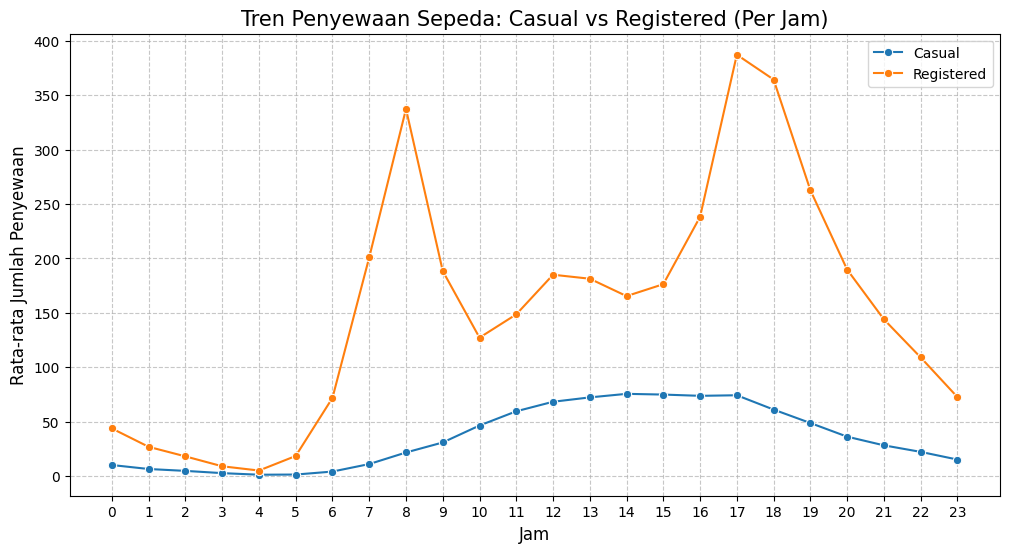

In [10]:
# Menyiapkan data
plt.figure(figsize=(12, 6))

# Membuat grafik garis
sns.lineplot(data=hour_analysis, x=hour_analysis.index, y='casual', label='Casual', marker='o')
sns.lineplot(data=hour_analysis, x=hour_analysis.index, y='registered', label='Registered', marker='o')

plt.title('Tren Penyewaan Sepeda: Casual vs Registered (Per Jam)', fontsize=15)
plt.xlabel('Jam', fontsize=12)
plt.ylabel('Rata-rata Jumlah Penyewaan', fontsize=12)
plt.xticks(range(0, 24))
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

plt.show()

### Pertanyaan 2:

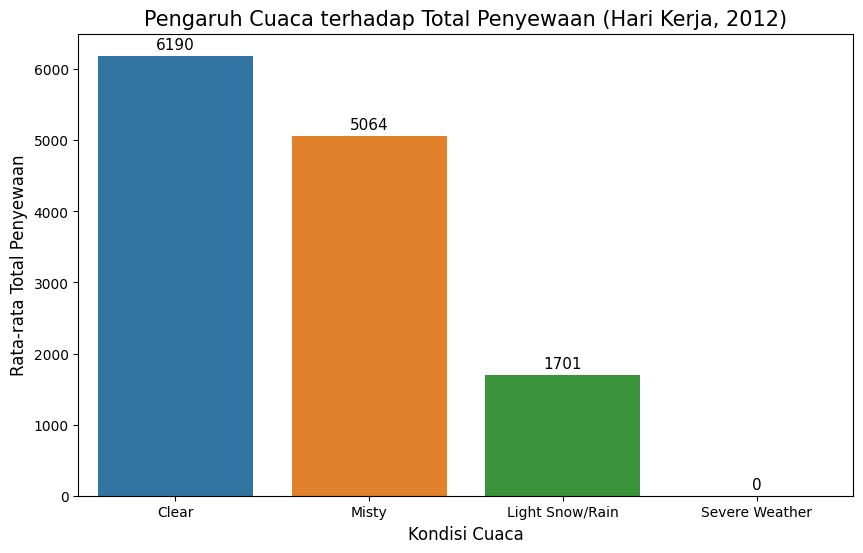

In [14]:
all_weathers = ['Clear', 'Misty', 'Light Snow/Rain', 'Severe Weather']

# Reindex agar kategori yang tidak ada di data tetap muncul dengan nilai 0
weather_graph_data = weather_workingday_2012.reindex(all_weathers, fill_value=0)

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'] # Example colors, you can customize this

plt.figure(figsize=(10, 6))
sns.barplot(
    x=weather_graph_data.index,
    y=weather_graph_data['cnt'],
    hue=weather_graph_data.index,
    palette=colors,
    legend=False,
)

plt.title('Pengaruh Cuaca terhadap Total Penyewaan (Hari Kerja, 2012)', fontsize=15)
plt.xlabel('Kondisi Cuaca', fontsize=12)
plt.ylabel('Rata-rata Total Penyewaan', fontsize=12)

# Tambahkan label angka di atas batang
for i, v in enumerate(weather_graph_data['cnt']):
    plt.text(i, v + 50, f'{v:.0f}', ha='center', va='bottom', fontsize=11)

plt.show()

**Insight:**

**Pertanyaan 1:**

Perbandingan Tren Casual vs Registered
Berdasarkan grafik garis tersebut, terdapat perbedaan perilaku yang sangat kontras antara kedua tipe pengguna:

- Pola Registered: Terdapat dua puncak (pikes) yang sangat tajam pada pukul 08:00 dan 17:00. Ini menunjukkan bahwa pengguna terdaftar adalah pekerja atau pelajar yang menggunakan sepeda sebagai alat transportasi rutin untuk berangkat dan pulang beraktivitas.

- Pola Casual: Pengguna casual tidak memiliki lonjakan tajam di jam sibuk pagi hari. Jumlah mereka mulai meningkat perlahan sejak pukul 10:00 hingga sore hari. Ini mengindikasikan bahwa mereka lebih banyak menggunakan sepeda untuk kegiatan santai atau wisata.

- Dominasi Pengguna: Di setiap jamnya, jumlah pengguna Registered jauh lebih tinggi daripada Casual, yang membuktikan bahwa basis pelanggan setia (langganan) adalah tulang punggung utama dari bisnis penyewaan ini.

**Pertanyaan 2:**

Grafik batang ini memberikan gambaran mengenai preferensi keamanan dan kenyamanan pengguna:

- Kondisi cuaca cerah: Cuaca cerah mendorong volume penyewaan tertinggi dengan rata-rata 6.190 unit. Pada kondisi ini, sepeda menjadi pilihan transportasi yang sangat populer bagi para pekerja di tahun 2012.

- Penurunan Akibat Cuaca: Terjadi penurunan volume penyewaan yang signifikan saat cuaca memburuk.

- Kondisi Ekstrem (Severe Weather): Angka 0 pada Severe Weather menunjukkan bahwa saat cuaca ekstrem, penyewaan berhenti total. Ini bisa disebabkan oleh kebijakan keselamatan dari penyedia layanan atau keputusan pengguna untuk tidak mengambil risiko sama sekali.

## Analisis Lanjutan (Opsional)

In [15]:
# Manual Clustering berdasarkan kategori waktu
def hour_clustering(hour):
    if 5 <= hour < 12:
        return "Pagi"
    elif 12 <= hour < 17:
        return "Siang"
    elif 17 <= hour < 21:
        return "Sore"
    else:
        return "Malam"

hour_df['time_category'] = hour_df['hr'].apply(hour_clustering)

# Agregasi untuk melihat kategori waktu mana yang paling ramai
time_cluster_df = hour_df.groupby(by="time_category").agg({
    "cnt": ["mean", "sum"]
}).sort_values(by=("cnt", "sum"), ascending=False)

time_cluster_df

cnt         
                     mean      sum
time_category                     
Sore           356.201441  1037971
Siang          262.244719   955882
Pagi           181.520583   921580
Malam           65.687968   377246

**Insight**

**Analisis Lanjutan:** Manual Clustering (Binning)

**Tujuan Analisis:**
Tujuan dari teknik ini adalah untuk menyederhanakan data waktu yang sangat detail (24 jam) ke dalam kelompok kategori waktu yang lebih bermakna secara bisnis (Pagi, Siang, Sore, Malam). Dengan melakukan binning atau pengelompokan manual, kita dapat mengidentifikasi periode waktu mana yang memberikan kontribusi penyewaan tertinggi dan terendah, sehingga memudahkan tim operasional dalam menentukan jadwal pemeliharaan armada serta strategi promosi yang lebih tepat sasaran.

**Teknik yang Digunakan:**
Analisis ini menggunakan metode Manual Grouping atau Binning. Teknik ini bekerja dengan cara membagi data numerik pada kolom hr (hour) ke dalam beberapa interval kategori berdasarkan aturan bisnis (business logic) sebagai berikut:

- Pagi (05:00 - 11:59): Mewakili jam berangkat aktivitas.

- Siang (12:00 - 16:59): Mewakili jam mobilitas siang hari dan rekreasi.

- Sore (17:00 - 20:59): Mewakili jam pulang aktivitas.

- Malam (21:00 - 04:59): Mewakili waktu istirahat dan jam operasional rendah.

**Interpretasi hasil clustering**
- Kategori Sore: Memiliki tingkat penggunaan tertinggi. Hal ini dipengaruhi oleh akumulasi pengguna yang pulang beraktivitas dan pengguna yang melakukan kegiatan rekreasi di penghujung hari.

- Kategori Siang: Menempati urutan kedua. Meskipun bukan waktu berangkat atau pulang kerja, volume penyewaan tetap tinggi yang mengindikasikan penggunaan sepeda untuk mobilitas jarak pendek atau wisata.

- Kategori Pagi: Menunjukkan aktivitas yang signifikan namun masih di bawah kategori sore. Puncak aktivitas di kelompok ini terkonsentrasi pada jam berangkat kerja (pukul 07:00 - 09:00).

- Kategori Malam: Memiliki volume penyewaan terendah dibandingkan kategori lainnya. Dari sisi operasional, periode ini dapat dimanfaatkan untuk melakukan pemeliharaan unit atau penataan ulang distribusi sepeda di setiap pos.

## Conclusion

**Pertanyaan 1:**

Analisis menunjukkan adanya perbedaan pola perilaku yang kontras antara pengguna Registered pada jam sibuk (08:00 dan 17:00) dengan pengguna Casual yang lebih cenderung menggunakan sepeda untuk rekreasi pada siang hingga sore hari. Sebagai langkah optimalisasi, pemilik bisnis disarankan untuk memperkuat loyalitas pengguna terdaftar melalui program membership atau poin khusus, sekaligus meluncurkan promo "Happy Hour" di jam non-sibuk (10:00 - 14:00) untuk menarik minat pengguna casual dan meningkatkan utilisasi armada yang menganggur di sela jam sibuk.

**Pertanyaan 2:**

Kondisi cuaca terbukti menjadi faktor penentu utama volume penyewaan pada hari kerja di tahun 2012, di mana cuaca Cerah (Clear) menghasilkan performa maksimal, sementara kondisi Hujan/Salju (Light Snow/Rain) memicu penurunan drastis. Untuk memitigasi risiko ini, pemilik bisnis perlu menerapkan strategi adaptif seperti pemberian diskon khusus hari hujan (Rainy Day Voucher) atau penyediaan fasilitas pelindung di docking station, serta memastikan seluruh jadwal pemeliharaan armada dilakukan pada malam hari saat volume penyewaan rendah guna menjamin ketersediaan unit tetap optimal di segala kondisi cuaca.

In [19]:
# Simpan dataframe hasil analisis ke CSV dengan nama main_data.csv
hour_df.to_csv("main_data.csv", index=False)